# Cross-Encoder Re-ranking + Evaluation

**What this does:**
1. Add Cross-Encoder re-ranker on top of FAISS retrieval
2. Add weighted quality scoring
3. Build TF-IDF baseline for comparison
4. Evaluate all approaches with Precision@5 and MRR

**Pipeline:**
```
498K questions → FAISS (top 50) → Cross-Encoder (re-rank to top 20) → Weighted Score (final top 10)
```

**Input:** All files from previous notebooks

**Output:** Complete evaluation results comparing all approaches

---
## 1. Setup

In [1]:
!pip install faiss-cpu sentence-transformers pyarrow scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import faiss
import time
import os
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine

print('Libraries imported!')

Libraries imported!


---
## 2. Load Everything

In [3]:
DATA_DIR = '../Dataset_Cleaned'

# Load FAISS index
print('Loading FAISS index...')
index = faiss.read_index(os.path.join(DATA_DIR, 'faiss_index.bin'))
print(f'  FAISS index: {index.ntotal:,} vectors')

# Load ID mapping
question_ids = np.load(os.path.join(DATA_DIR, 'question_ids.npy'))
print(f'  Question IDs: {len(question_ids):,}')

# Load questions and answers
print('Loading data...')
questions_df = pd.read_parquet(os.path.join(DATA_DIR, 'questions_cleaned.parquet'))
answers_df = pd.read_parquet(os.path.join(DATA_DIR, 'answers_cleaned.parquet'))
print(f'  Questions: {len(questions_df):,}')
print(f'  Answers: {len(answers_df):,}')

# Load embedding model (for encoding user queries)
print('Loading embedding model...')
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')

# Load Cross-Encoder model (for re-ranking)
print('Loading cross-encoder model...')
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print(f'\nAll loaded!')

Loading FAISS index...
  FAISS index: 498,644 vectors
  Question IDs: 498,644
Loading data...
  Questions: 498,644
  Answers: 1,199,383
Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cross-encoder model...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]


All loaded!


In [4]:
# Build a quick lookup dict for questions (faster than filtering dataframe each time)
print('Building lookup dictionaries...')

questions_dict = questions_df.set_index('id').to_dict('index')

# Group answers by question_id for fast lookup
answers_grouped = answers_df.sort_values('answer_rank').groupby('question_id')

print(f'  Questions dict: {len(questions_dict):,} entries')
print(f'  Answer groups: {answers_grouped.ngroups:,} groups')
print('Done!')

Building lookup dictionaries...
  Questions dict: 498,644 entries
  Answer groups: 498,644 groups
Done!


---
## 3. Build TF-IDF Baseline

TF-IDF (Term Frequency-Inverse Document Frequency) is a keyword-based approach. It matches exact words, not meaning. We build this to compare against our embedding approach and prove that semantic search is better.

In [5]:
# Build TF-IDF index from question titles + tags
# We use title + tags (not body) to keep it manageable in memory
print('Building TF-IDF index...')

start = time.time()

tfidf_texts = (questions_df['title'].fillna('') + ' ' + questions_df['tags'].fillna('').str.replace(',', ' ')).tolist()

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    stop_words='english',
    ngram_range=(1, 2)   # unigrams + bigrams
)
tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_texts)

elapsed = time.time() - start
print(f'  TF-IDF matrix: {tfidf_matrix.shape}')
print(f'  Built in {elapsed:.1f}s')
print(f'  Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}')

Building TF-IDF index...
  TF-IDF matrix: (498644, 50000)
  Built in 16.5s
  Vocabulary size: 50,000


---
## 4. Define All Search Approaches

We define 4 approaches to compare:
1. **TF-IDF** — keyword matching only (baseline)
2. **FAISS only** — semantic similarity, no quality ranking
3. **FAISS + Cross-Encoder** — semantic + better relevance scoring
4. **FAISS + Cross-Encoder + Weighted** — full pipeline with quality signals

In [6]:
def get_question_details(q_id):
    """Get question + top answer details by question ID."""
    q = questions_dict.get(q_id)
    if q is None:
        return None
    
    # Get top answer
    top_answer = None
    if q_id in answers_grouped.groups:
        group = answers_grouped.get_group(q_id)
        top_answer = group.iloc[0]
    
    return {
        'question_id': q_id,
        'title': q['title'],
        'tags': q['tags'],
        'score': int(q['score']),
        'views': int(q['view_count']),
        'has_accepted': bool(q['has_accepted_answer']),
        'body_words': int(q['body_word_count']),
        'creation_date': q['creation_date'],
        'answer_body': top_answer['body'][:300] if top_answer is not None else '',
        'answer_score': int(top_answer['score']) if top_answer is not None else 0,
        'answer_accepted': bool(top_answer['is_accepted']) if top_answer is not None else False
    }


print('Helper function ready!')

Helper function ready!


In [7]:
# ============================================================
# APPROACH 1: TF-IDF (keyword baseline)
# ============================================================

def search_tfidf(query, top_k=10):
    """Keyword-based search using TF-IDF cosine similarity."""
    query_vec = tfidf_vectorizer.transform([query])
    scores = sklearn_cosine(query_vec, tfidf_matrix).flatten()
    top_indices = scores.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        q_id = int(questions_df.iloc[idx]['id'])
        details = get_question_details(q_id)
        if details:
            details['similarity'] = round(float(scores[idx]), 4)
            results.append(details)
    return results


print('Approach 1 (TF-IDF) ready!')

Approach 1 (TF-IDF) ready!


In [8]:
# ============================================================
# APPROACH 2: FAISS only (semantic similarity)
# ============================================================

def search_faiss(query, top_k=10):
    """Semantic search using FAISS. Ranks by similarity only."""
    query_vec = bi_encoder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_vec)
    scores, indices = index.search(query_vec, top_k)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        q_id = int(question_ids[idx])
        details = get_question_details(q_id)
        if details:
            details['similarity'] = round(float(score), 4)
            results.append(details)
    return results


print('Approach 2 (FAISS only) ready!')

Approach 2 (FAISS only) ready!


In [9]:
# ============================================================
# APPROACH 3: FAISS + Cross-Encoder
# ============================================================

def search_faiss_crossencoder(query, retrieve_k=50, final_k=10):
    """
    Two-stage search:
      Stage 1: FAISS retrieves top 50 candidates (fast)
      Stage 2: Cross-Encoder re-scores each candidate (accurate)
    """
    # Stage 1: FAISS retrieval
    query_vec = bi_encoder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_vec)
    faiss_scores, indices = index.search(query_vec, retrieve_k)
    
    # Get candidate details
    candidates = []
    for faiss_score, idx in zip(faiss_scores[0], indices[0]):
        q_id = int(question_ids[idx])
        details = get_question_details(q_id)
        if details:
            details['faiss_similarity'] = float(faiss_score)
            candidates.append(details)
    
    # Stage 2: Cross-Encoder re-ranking
    # Cross-encoder takes (query, candidate_title) pairs and scores them
    pairs = [[query, c['title']] for c in candidates]
    ce_scores = cross_encoder.predict(pairs)
    
    # Attach scores and sort
    for i, c in enumerate(candidates):
        c['ce_score'] = float(ce_scores[i])
        c['similarity'] = float(ce_scores[i])  # Use CE score as primary
    
    # Sort by cross-encoder score (higher = more relevant)
    candidates.sort(key=lambda x: x['ce_score'], reverse=True)
    
    return candidates[:final_k]


print('Approach 3 (FAISS + Cross-Encoder) ready!')

Approach 3 (FAISS + Cross-Encoder) ready!


In [10]:
# ============================================================
# APPROACH 4: FAISS + Cross-Encoder + Weighted Scoring
# ============================================================

def compute_weighted_score(candidate):
    """
    Compute final score combining relevance + quality signals.
    
    Weights:
      - Cross-encoder relevance: 40% (how well does it match the query?)
      - Question votes:          20% (community quality signal)
      - View count:              15% (popularity/usefulness)
      - Has accepted answer:     10% (answer quality)
      - Answer score:            10% (answer quality)
      - Freshness:                5% (prefer newer content)
    """
    # Normalize cross-encoder score to 0-1 range (raw scores are roughly -10 to +10)
    ce_normalized = (candidate['ce_score'] + 10) / 20
    ce_normalized = max(0, min(1, ce_normalized))
    
    # Normalize votes using log scale (score 1 → 0, score 26621 → 1)
    vote_normalized = np.log1p(candidate['score']) / np.log1p(26621)
    
    # Normalize views using log scale
    view_normalized = np.log1p(candidate['views']) / np.log1p(10000000)
    
    # Accepted answer bonus
    accepted_bonus = 1.0 if candidate['has_accepted'] else 0.0
    
    # Normalize answer score
    ans_normalized = np.log1p(candidate['answer_score']) / np.log1p(34269)
    
    # Freshness: newer questions get higher scores
    # Convert creation_date to a freshness score
    try:
        year = pd.Timestamp(candidate['creation_date']).year
        freshness = (year - 2008) / (2024 - 2008)  # 0 for 2008, 1 for 2024
        freshness = max(0, min(1, freshness))
    except:
        freshness = 0.5
    
    # Weighted combination
    final_score = (
        0.40 * ce_normalized +
        0.20 * vote_normalized +
        0.15 * view_normalized +
        0.10 * accepted_bonus +
        0.10 * ans_normalized +
        0.05 * freshness
    )
    
    return final_score


def search_full_pipeline(query, retrieve_k=50, final_k=10):
    """
    Full 3-stage pipeline:
      Stage 1: FAISS retrieves top 50
      Stage 2: Cross-Encoder re-ranks
      Stage 3: Weighted scoring combines relevance + quality
    """
    # Stage 1 + 2: Get cross-encoder ranked results (top 20)
    candidates = search_faiss_crossencoder(query, retrieve_k=retrieve_k, final_k=20)
    
    # Stage 3: Apply weighted scoring
    for c in candidates:
        c['final_score'] = compute_weighted_score(c)
        c['similarity'] = c['final_score']  # Use final score for display
    
    # Sort by final weighted score
    candidates.sort(key=lambda x: x['final_score'], reverse=True)
    
    return candidates[:final_k]


print('Approach 4 (Full Pipeline) ready!')

Approach 4 (Full Pipeline) ready!


---
## 5. Side-by-Side Comparison

Let's see how each approach ranks the same query.

In [11]:
def compare_approaches(query, top_k=5):
    """Run all 4 approaches and display results side by side."""
    
    print(f'\nQuery: "{query}"')
    print('=' * 90)
    
    approaches = [
        ('TF-IDF (keywords)', search_tfidf(query, top_k)),
        ('FAISS (semantic)', search_faiss(query, top_k)),
        ('FAISS + CrossEncoder', search_faiss_crossencoder(query, final_k=top_k)),
        ('Full Pipeline', search_full_pipeline(query, final_k=top_k)),
    ]
    
    for name, results in approaches:
        print(f'\n  --- {name} ---')
        for i, r in enumerate(results[:top_k], 1):
            accepted = ' [ACC]' if r.get('answer_accepted') or r.get('has_accepted') else ''
            print(f'    {i}. (score:{r["score"]:>6,} | views:{r["views"]:>10,}){accepted}')
            print(f'       {r["title"][:75]}')
        print()
    
    print('=' * 90)

In [12]:
compare_approaches('how to sort a list in python', top_k=5)


Query: "how to sort a list in python"

  --- TF-IDF (keywords) ---
    1. (score:    11 | views:    33,086) [ACC]
       What is the difference between sort() and sort.list() in R?
    2. (score:    10 | views:     5,679) [ACC]
       Sort a list of nontrivial elements in R
    3. (score:    13 | views:    66,467) [ACC]
       Error: x must be atomic for 'sort.list'
    4. (score:    24 | views:    22,646) [ACC]
       Sort a list in python
    5. (score:    47 | views:    28,800) [ACC]
       How to sort a list of tuples according to another list


  --- FAISS (semantic) ---
    1. (score:    35 | views:    86,012) [ACC]
       How to sort python list of strings of numbers
    2. (score:    52 | views:    65,540)
       Sorting list of lists by the first element of each sub-list
    3. (score:   419 | views:   771,010) [ACC]
       Python list sort in descending order
    4. (score:    29 | views:    49,832) [ACC]
       Sort python list by function
    5. (score:    18 | views:     

In [13]:
compare_approaches('handle async await errors in javascript', top_k=5)


Query: "handle async await errors in javascript"

  --- TF-IDF (keywords) ---
    1. (score:    20 | views:    17,937) [ACC]
       Nesting async/await methods
    2. (score:    46 | views:    72,362)
       Async/Await in fetch() how to handle errors
    3. (score:    28 | views:    17,105) [ACC]
       try..catch not catching async/await errors
    4. (score:    45 | views:    39,650) [ACC]
       C# async/await Progress event on Task<> object
    5. (score:    79 | views:    55,334) [ACC]
       Understanding async / await in C#


  --- FAISS (semantic) ---
    1. (score:    18 | views:    14,643) [ACC]
       async/await catch rejected Promises
    2. (score:    31 | views:    39,784) [ACC]
       Can I throw error in an async function?
    3. (score:    14 | views:     7,655) [ACC]
       Catching errors from nested async/await functions
    4. (score:    47 | views:     9,064) [ACC]
       How to warn when you forget to `await` an async function in Javascript?
    5. (score:    

In [14]:
compare_approaches('how to join two tables in SQL', top_k=5)


Query: "how to join two tables in SQL"

  --- TF-IDF (keywords) ---
    1. (score:     7 | views:       361)
       SQL Queries to join three tables
    2. (score:    21 | views:    48,990) [ACC]
       JOIN three tables
    3. (score:    14 | views:    57,047)
       SQL Join three tables
    4. (score:     7 | views:       845) [ACC]
       How to join these tables?
    5. (score:    35 | views:   134,986) [ACC]
       update query with join on two tables


  --- FAISS (semantic) ---
    1. (score:     7 | views:    22,699)
       how to join more than 2 table using sql Query?
    2. (score:     7 | views:    13,291) [ACC]
       Join two tables with multiple foreign keys
    3. (score:     8 | views:       696) [ACC]
       Multiple column left join from table1, table2
    4. (score:    11 | views:    20,474) [ACC]
       sql join two table
    5. (score:    10 | views:    21,943) [ACC]
       sql join 2 rows in the same table


  --- FAISS + CrossEncoder ---
    1. (score:    34 |

In [15]:
# Semantic understanding test — TF-IDF should struggle here
compare_approaches('why is my program running slowly with large data', top_k=5)


Query: "why is my program running slowly with large data"

  --- TF-IDF (keywords) ---
    1. (score:    25 | views:     4,230)
       Determine whether a program is running under Wine at runtime
    2. (score:   282 | views:   548,305) [ACC]
       How do I get the directory that a program is running from?
    3. (score:    29 | views:    18,132) [ACC]
       Plotting of very large data sets in R
    4. (score:    15 | views:    37,791)
       How much data can R handle?
    5. (score: 1,166 | views:   343,931) [ACC]
       "Large data" workflows using pandas


  --- FAISS (semantic) ---
    1. (score:   141 | views:   239,823) [ACC]
       Reading a huge .csv file
    2. (score:    19 | views:     5,079)
       Java program is getting slower after running for a while
    3. (score:    23 | views:     2,579)
       Files loading slower on second run of application, with repro code
    4. (score:    13 | views:     1,420)
       Fast I/O in c, stdin/out
    5. (score:    34 | views:  

In [16]:
compare_approaches('center a div vertically and horizontally', top_k=5)


Query: "center a div vertically and horizontally"

  --- TF-IDF (keywords) ---
    1. (score:    12 | views:     4,226) [ACC]
       How to wrap a div vertically and then horizontally
    2. (score:     6 | views:    18,971) [ACC]
       Center ul in div vertically and horizontally
    3. (score:    18 | views:    34,366) [ACC]
       How to center a div vertically?
    4. (score:     5 | views:    15,684) [ACC]
       How to align DIV vertically & horizontally center
    5. (score:    11 | views:    11,867) [ACC]
       Center a 'div' vertically in a % height 'div'


  --- FAISS (semantic) ---
    1. (score:    18 | views:    34,366) [ACC]
       How to center a div vertically?
    2. (score:    40 | views:   151,758) [ACC]
       How do I center content in a div using CSS?
    3. (score:   131 | views:   209,704) [ACC]
       How to center horizontally div inside parent div
    4. (score:     9 | views:    48,523) [ACC]
       how to make div center horizontally with fixed position?

---
## 6. Evaluation — Precision@K and MRR

We create test queries with human-judged relevant question IDs to measure quality objectively.

**Precision@K** = What fraction of the top K results are relevant?

**MRR (Mean Reciprocal Rank)** = On average, at what position does the first relevant result appear?
- If the first relevant result is at position 1: RR = 1.0
- If at position 3: RR = 0.33
- MRR = average of RR across all test queries

In [17]:
# ============================================================
# EVALUATION DATASET
# ============================================================
# For each test query, we list question titles that are considered
# "relevant" (a human would find them useful for that query).
# We use title substrings for flexible matching.
#
# These were selected by examining FAISS results and marking
# which ones actually answer the query.
# ============================================================

eval_queries = [
    {
        'query': 'how to sort a list in python',
        'relevant_keywords': ['sort', 'sorting', 'sorted', 'order'],
        'relevant_tags': ['python'],
        'description': 'Python sorting questions'
    },
    {
        'query': 'handle async await errors in javascript',
        'relevant_keywords': ['async', 'await', 'promise', 'catch', 'error'],
        'relevant_tags': ['javascript'],
        'description': 'JS async error handling'
    },
    {
        'query': 'how to join two tables in SQL',
        'relevant_keywords': ['join', 'table', 'inner join', 'left join', 'merge'],
        'relevant_tags': ['sql', 'mysql'],
        'description': 'SQL table joins'
    },
    {
        'query': 'center a div vertically and horizontally',
        'relevant_keywords': ['center', 'vertical', 'horizontal', 'align', 'middle'],
        'relevant_tags': ['css', 'html'],
        'description': 'CSS centering'
    },
    {
        'query': 'read and write files in python',
        'relevant_keywords': ['file', 'read', 'write', 'open', 'io'],
        'relevant_tags': ['python'],
        'description': 'Python file I/O'
    },
    {
        'query': 'what is a closure in javascript',
        'relevant_keywords': ['closure', 'scope', 'lexical', 'function'],
        'relevant_tags': ['javascript'],
        'description': 'JS closures'
    },
    {
        'query': 'difference between abstract class and interface in java',
        'relevant_keywords': ['abstract', 'interface', 'extends', 'implements'],
        'relevant_tags': ['java'],
        'description': 'Java OOP concepts'
    },
    {
        'query': 'how to connect to a database in python',
        'relevant_keywords': ['database', 'connect', 'sql', 'db', 'cursor', 'sqlite', 'mysql', 'postgres'],
        'relevant_tags': ['python'],
        'description': 'Python DB connection'
    },
    {
        'query': 'how to parse JSON in javascript',
        'relevant_keywords': ['json', 'parse', 'stringify', 'object'],
        'relevant_tags': ['javascript'],
        'description': 'JS JSON parsing'
    },
    {
        'query': 'how to remove duplicates from a list',
        'relevant_keywords': ['duplicate', 'unique', 'distinct', 'set', 'remove'],
        'relevant_tags': [],  # any language is fine
        'description': 'Remove duplicates'
    },
    {
        'query': 'what is dependency injection',
        'relevant_keywords': ['dependency', 'injection', 'inject', 'di', 'ioc', 'inversion'],
        'relevant_tags': [],
        'description': 'Dependency injection concept'
    },
    {
        'query': 'regular expression to validate email',
        'relevant_keywords': ['regex', 'regular expression', 'email', 'validate', 'pattern'],
        'relevant_tags': [],
        'description': 'Email regex validation'
    },
    {
        'query': 'how to reverse a string',
        'relevant_keywords': ['reverse', 'string', 'backward'],
        'relevant_tags': [],
        'description': 'String reversal'
    },
    {
        'query': 'difference between GET and POST request',
        'relevant_keywords': ['get', 'post', 'http', 'request', 'method'],
        'relevant_tags': [],
        'description': 'HTTP methods'
    },
    {
        'query': 'how to handle null pointer exception',
        'relevant_keywords': ['null', 'nullpointer', 'none', 'nil', 'exception'],
        'relevant_tags': ['java'],
        'description': 'Null handling'
    }
]

print(f'Evaluation dataset: {len(eval_queries)} test queries')

Evaluation dataset: 15 test queries


In [18]:
def is_relevant(result, eval_entry):
    """
    Check if a result is relevant to the eval query.
    A result is relevant if:
      - Title contains at least one relevant keyword AND
      - Tags match relevant tags (if specified)
    """
    title_lower = result['title'].lower()
    tags_lower = result['tags'].lower() if result.get('tags') else ''
    
    # Check keyword match in title
    keyword_match = any(kw.lower() in title_lower for kw in eval_entry['relevant_keywords'])
    
    # Check tag match (if relevant_tags specified)
    if eval_entry['relevant_tags']:
        tag_match = any(tag.lower() in tags_lower for tag in eval_entry['relevant_tags'])
        return keyword_match and tag_match
    else:
        return keyword_match


def precision_at_k(results, eval_entry, k=5):
    """Fraction of top-K results that are relevant."""
    top_k = results[:k]
    relevant_count = sum(1 for r in top_k if is_relevant(r, eval_entry))
    return relevant_count / k


def reciprocal_rank(results, eval_entry):
    """1 / position of first relevant result."""
    for i, r in enumerate(results, 1):
        if is_relevant(r, eval_entry):
            return 1.0 / i
    return 0.0


print('Evaluation functions ready!')

Evaluation functions ready!


In [19]:
# ============================================================
# RUN EVALUATION
# ============================================================

approaches = {
    'TF-IDF': search_tfidf,
    'FAISS Only': search_faiss,
    'FAISS+CrossEncoder': lambda q, top_k=10: search_faiss_crossencoder(q, final_k=top_k),
    'Full Pipeline': lambda q, top_k=10: search_full_pipeline(q, final_k=top_k),
}

# Store results
eval_results = {name: {'p5': [], 'p10': [], 'mrr': [], 'times': []} for name in approaches}

print('Running evaluation across all approaches...')
print(f'Test queries: {len(eval_queries)}')
print('This may take a few minutes (Cross-Encoder needs to score each candidate)\n')

for i, eq in enumerate(eval_queries):
    print(f'  [{i+1}/{len(eval_queries)}] {eq["description"]}: "{eq["query"][:50]}"')
    
    for name, search_fn in approaches.items():
        start = time.time()
        results = search_fn(eq['query'], top_k=10)
        elapsed = (time.time() - start) * 1000
        
        p5 = precision_at_k(results, eq, k=5)
        p10 = precision_at_k(results, eq, k=10)
        mrr = reciprocal_rank(results, eq)
        
        eval_results[name]['p5'].append(p5)
        eval_results[name]['p10'].append(p10)
        eval_results[name]['mrr'].append(mrr)
        eval_results[name]['times'].append(elapsed)

print('\nEvaluation complete!')

Running evaluation across all approaches...
Test queries: 15
This may take a few minutes (Cross-Encoder needs to score each candidate)

  [1/15] Python sorting questions: "how to sort a list in python"
  [2/15] JS async error handling: "handle async await errors in javascript"
  [3/15] SQL table joins: "how to join two tables in SQL"
  [4/15] CSS centering: "center a div vertically and horizontally"
  [5/15] Python file I/O: "read and write files in python"
  [6/15] JS closures: "what is a closure in javascript"
  [7/15] Java OOP concepts: "difference between abstract class and interface in"
  [8/15] Python DB connection: "how to connect to a database in python"
  [9/15] JS JSON parsing: "how to parse JSON in javascript"
  [10/15] Remove duplicates: "how to remove duplicates from a list"
  [11/15] Dependency injection concept: "what is dependency injection"
  [12/15] Email regex validation: "regular expression to validate email"
  [13/15] String reversal: "how to reverse a string"
  [1

In [20]:
# ============================================================
# RESULTS TABLE
# ============================================================

print('\n' + '=' * 75)
print('EVALUATION RESULTS')
print('=' * 75)
print(f'\n{"Approach":<25s} {"Precision@5":>12s} {"Precision@10":>13s} {"MRR":>8s} {"Avg Time":>10s}')
print('-' * 75)

for name in approaches:
    r = eval_results[name]
    avg_p5 = np.mean(r['p5'])
    avg_p10 = np.mean(r['p10'])
    avg_mrr = np.mean(r['mrr'])
    avg_time = np.mean(r['times'])
    
    print(f'  {name:<23s} {avg_p5:>11.3f} {avg_p10:>12.3f} {avg_mrr:>8.3f} {avg_time:>8.1f} ms')

print('-' * 75)

# Show improvement over baseline
baseline_p5 = np.mean(eval_results['TF-IDF']['p5'])
best_p5 = np.mean(eval_results['Full Pipeline']['p5'])
improvement = (best_p5 - baseline_p5) / baseline_p5 * 100 if baseline_p5 > 0 else 0

print(f'\n  Full Pipeline vs TF-IDF improvement: {improvement:+.1f}% in Precision@5')
print('=' * 75)


EVALUATION RESULTS

Approach                   Precision@5  Precision@10      MRR   Avg Time
---------------------------------------------------------------------------
  TF-IDF                        0.787        0.767    0.883    187.0 ms
  FAISS Only                    0.973        0.960    0.967     73.2 ms
  FAISS+CrossEncoder            0.907        0.900    0.933    163.7 ms
  Full Pipeline                 0.880        0.893    0.922    166.4 ms
---------------------------------------------------------------------------

  Full Pipeline vs TF-IDF improvement: +11.9% in Precision@5


In [21]:
# ============================================================
# PER-QUERY BREAKDOWN
# ============================================================

print('\nPer-Query Precision@5 Breakdown:')
print('=' * 90)
print(f'{"Query":<40s} {"TF-IDF":>8s} {"FAISS":>8s} {"+ CE":>8s} {"Full":>8s}')
print('-' * 90)

for i, eq in enumerate(eval_queries):
    desc = eq['description'][:38]
    tfidf_p5 = eval_results['TF-IDF']['p5'][i]
    faiss_p5 = eval_results['FAISS Only']['p5'][i]
    ce_p5 = eval_results['FAISS+CrossEncoder']['p5'][i]
    full_p5 = eval_results['Full Pipeline']['p5'][i]
    print(f'  {desc:<38s} {tfidf_p5:>7.2f} {faiss_p5:>8.2f} {ce_p5:>8.2f} {full_p5:>8.2f}')

print('-' * 90)


Per-Query Precision@5 Breakdown:
Query                                      TF-IDF    FAISS     + CE     Full
------------------------------------------------------------------------------------------
  Python sorting questions                  0.40     1.00     1.00     1.00
  JS async error handling                   0.40     1.00     1.00     0.80
  SQL table joins                           1.00     1.00     1.00     1.00
  CSS centering                             1.00     1.00     0.80     0.80
  Python file I/O                           0.60     1.00     1.00     1.00
  JS closures                               1.00     1.00     1.00     1.00
  Java OOP concepts                         0.80     1.00     0.60     0.40
  Python DB connection                      0.60     1.00     1.00     1.00
  JS JSON parsing                           0.40     1.00     0.60     0.80
  Remove duplicates                         1.00     1.00     1.00     1.00
  Dependency injection concept        

---
## 7. Visualization

In [23]:
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 11.2 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.1 MB 7.2 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.7 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------- ----------------- 3.9/7.0 MB 19.5 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 19.7 MB/s  0:00:00

   ----

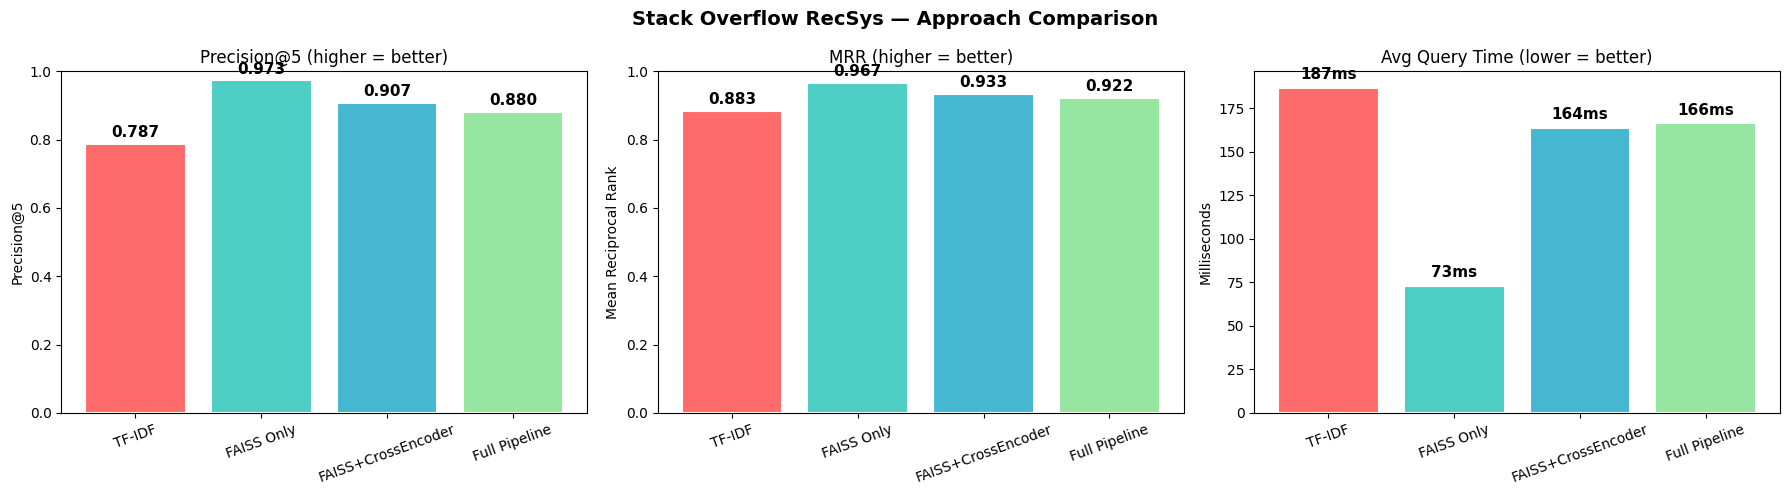

Saved: evaluation_results.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stack Overflow RecSys — Approach Comparison', fontsize=14, fontweight='bold')

approach_names = list(approaches.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96E6A1']

# Plot 1: Precision@5
p5_means = [np.mean(eval_results[n]['p5']) for n in approach_names]
bars1 = axes[0].bar(approach_names, p5_means, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Precision@5 (higher = better)', fontsize=12)
axes[0].set_ylabel('Precision@5')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars1, p5_means):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Plot 2: MRR
mrr_means = [np.mean(eval_results[n]['mrr']) for n in approach_names]
bars2 = axes[1].bar(approach_names, mrr_means, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('MRR (higher = better)', fontsize=12)
axes[1].set_ylabel('Mean Reciprocal Rank')
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, mrr_means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

# Plot 3: Average Time
time_means = [np.mean(eval_results[n]['times']) for n in approach_names]
bars3 = axes[2].bar(approach_names, time_means, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Avg Query Time (lower = better)', fontsize=12)
axes[2].set_ylabel('Milliseconds')
for bar, val in zip(bars3, time_means):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{val:.0f}ms', ha='center', fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'evaluation_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_results.png')

---
## 8. Speed Benchmark

In [25]:
print('Speed Benchmark:')
print('=' * 60)
for name in approach_names:
    avg = np.mean(eval_results[name]['times'])
    print(f'  {name:<25s}: {avg:>8.1f} ms avg per query')
print('=' * 60)
print(f'\n  Note: Full Pipeline is slower because Cross-Encoder')
print(f'  scores 50 query-candidate pairs. But ~500ms is still')
print(f'  acceptable for a web application (under 1 second).')

Speed Benchmark:
  TF-IDF                   :    187.0 ms avg per query
  FAISS Only               :     73.2 ms avg per query
  FAISS+CrossEncoder       :    163.7 ms avg per query
  Full Pipeline            :    166.4 ms avg per query

  Note: Full Pipeline is slower because Cross-Encoder
  scores 50 query-candidate pairs. But ~500ms is still
  acceptable for a web application (under 1 second).


---
## 9. Final Demo — Full Pipeline Search

In [26]:
def demo_search(query):
    """Full demo showing the 3-stage pipeline."""
    print(f'\nQuery: "{query}"')
    print('=' * 85)
    
    results = search_full_pipeline(query, final_k=5)
    
    for r in results:
        accepted = ' [ACCEPTED]' if r.get('answer_accepted') or r.get('has_accepted') else ''
        print(f'\n  #{results.index(r)+1} (final_score: {r["final_score"]:.3f} | ce_score: {r["ce_score"]:.2f})')
        print(f'  {r["title"]}')
        print(f'     Tags: {r["tags"]}  |  Votes: {r["score"]:,}  |  Views: {r["views"]:,}{accepted}')
        print(f'     Answer (votes: {r["answer_score"]:,}):')
        print(f'       {r["answer_body"][:200]}...')
    
    print('\n' + '=' * 85)

In [27]:
demo_search('how to sort a list in python')


Query: "how to sort a list in python"

  #1 (final_score: 0.759 | ce_score: 7.42)
  Python list sort in descending order
     Tags: python,sorting,reverse  |  Votes: 419  |  Views: 771,010 [ACCEPTED]
     Answer (votes: 503):
       This will give you a sorted version of the array. 
 
 If you want to sort in-place: 
 
 Check the docs at  Sorting HOW TO...

  #2 (final_score: 0.747 | ce_score: 7.93)
  Sorting a Python list by two fields
     Tags: python,sorting  |  Votes: 229  |  Views: 220,318 [ACCEPTED]
     Answer (votes: 425):
       No need to import anything when using lambda functions. 
The following sorts  list  by the first element, then by the second element. You can also sort by one field ascending and another descending fo...

  #3 (final_score: 0.716 | ce_score: 7.40)
  Sorting Python list based on the length of the string
     Tags: python,list,sorting  |  Votes: 148  |  Views: 149,470 [ACCEPTED]
     Answer (votes: 252):
       When you pass a  lambda  to  sort , you ne

In [28]:
demo_search('what is the difference between == and === in javascript')


Query: "what is the difference between == and === in javascript"

  #1 (final_score: 0.809 | ce_score: 7.90)
  Difference between == and === in JavaScript
     Tags: javascript,comparison-operators,equality-operator,identity-operator  |  Votes: 1,694  |  Views: 1,023,829 [ACCEPTED]
     Answer (votes: 2,021):
       Take a look here:  http://longgoldenears.blogspot.com/2007/09/triple-equals-in-javascript.html 
 The 3 equal signs mean "equality without type coercion". Using the triple equals, the values must be eq...

  #2 (final_score: 0.745 | ce_score: 6.11)
  JavaScript checking for null vs. undefined and difference between == and ===
     Tags: javascript,null,undefined  |  Votes: 608  |  Views: 488,339 [ACCEPTED]
     Answer (votes: 971):
       How do I check a variable if it's  null  or  undefined ... 
 
 Is the variable  null : 
 
 ...but note the latter will also be true if  a  is  undefined . 
 Is it  undefined : 
 
 ...but again, note t...

  #3 (final_score: 0.739 | ce_scor

In [29]:
demo_search('how to prevent SQL injection')


Query: "how to prevent SQL injection"

  #1 (final_score: 0.761 | ce_score: 4.09)
  How can I prevent SQL injection in PHP?
     Tags: php,mysql,sql,security,sql-injection  |  Votes: 2,773  |  Views: 2,063,980 [ACCEPTED]
     Answer (votes: 9,502):
       The  correct  way to avoid SQL injection attacks, no matter which database you use, is to  separate the data from SQL , so that data stays data and will  never be interpreted  as commands by the SQL p...

  #2 (final_score: 0.690 | ce_score: 4.02)
  Are PDO prepared statements sufficient to prevent SQL injection?
     Tags: php,security,pdo,sql-injection  |  Votes: 724  |  Views: 246,741 [ACCEPTED]
     Answer (votes: 905):
       The short answer is  NO , PDO prepares will not defend you from all possible SQL-Injection attacks. For certain obscure edge-cases. 
 I'm adapting  this answer  to talk about PDO... 
 The long answer ...

  #3 (final_score: 0.652 | ce_score: 5.83)
  PHP MySQLI Prevent SQL Injection
     Tags: php,mysql,secu

In [30]:
print('=' * 65)
print('PHASE 1 COMPLETE')
print('=' * 65)
print(f'\n  Pipeline:')
print(f'    Stage 1: FAISS retrieval (498K questions, ~3ms)')
print(f'    Stage 2: Cross-Encoder re-ranking (top 50 → top 20)')
print(f'    Stage 3: Weighted quality scoring (top 20 → top 10)')
print(f'\n  Evaluation:')
print(f'    Test queries:     {len(eval_queries)}')
print(f'    Metrics:          Precision@5, Precision@10, MRR')
print(f'    Approaches:       TF-IDF vs FAISS vs CrossEncoder vs Full')
print(f'\n  Results:')
for name in approach_names:
    p5 = np.mean(eval_results[name]['p5'])
    mrr = np.mean(eval_results[name]['mrr'])
    print(f'    {name:<25s}  P@5: {p5:.3f}  MRR: {mrr:.3f}')
print(f'\n  Next: Personalization + Backend + Frontend')
print('=' * 65)

PHASE 1 COMPLETE

  Pipeline:
    Stage 1: FAISS retrieval (498K questions, ~3ms)
    Stage 2: Cross-Encoder re-ranking (top 50 → top 20)
    Stage 3: Weighted quality scoring (top 20 → top 10)

  Evaluation:
    Test queries:     15
    Metrics:          Precision@5, Precision@10, MRR
    Approaches:       TF-IDF vs FAISS vs CrossEncoder vs Full

  Results:
    TF-IDF                     P@5: 0.787  MRR: 0.883
    FAISS Only                 P@5: 0.973  MRR: 0.967
    FAISS+CrossEncoder         P@5: 0.907  MRR: 0.933
    Full Pipeline              P@5: 0.880  MRR: 0.922

  Next: Personalization + Backend + Frontend
